In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import torch as th
import torch.nn.functional as F
from matplotlib.cm import ScalarMappable
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch_geometric.nn import VGAE, GCNConv
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import from_networkx, to_networkx

/usr/lib/python3/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1)  IMPORT 
# import graph de l'aéroport
chemin_xml = "../data/airportsAndCoordAndPop.graphml"
graph  = nx.read_graphml(chemin_xml)
# conversion du graph et attribution des caractéristiques aux noeuds
data=from_networkx(graph, group_node_attrs=["lon", "lat", "population"])


In [3]:
pays = data['country']
ville = data['city_name']
# décompte des occurrences de chaque pays
#from collections import Counter
#freq = Counter(pays)
#print(freq)  # Output: Counter({'c': 3, 'a': 2, 'b': 1})   

import pandas as pd
lespays=pd.Series(pays).value_counts()

# nombre de connexions  par aéroport
edge=data.edge_index 
nb_connection = edge.size(1)
print(nb_connection)
# nombre de connexions par aéroport

nb_connection_sortantes = pd.Series(edge[0].tolist()).value_counts().rename_axis('airport').reset_index(name='nb_sortantes')
# stat sur les connexions sortantes par aéroport
# hum , j'ai l'impression que le graph n'est pas dirigé: les connexions entrantes et sortantes sont similaires
nb_connection_entrantes = pd.Series(edge[1].tolist()).value_counts().rename_axis('airport').reset_index(name='nb_entrantes')

    



27094


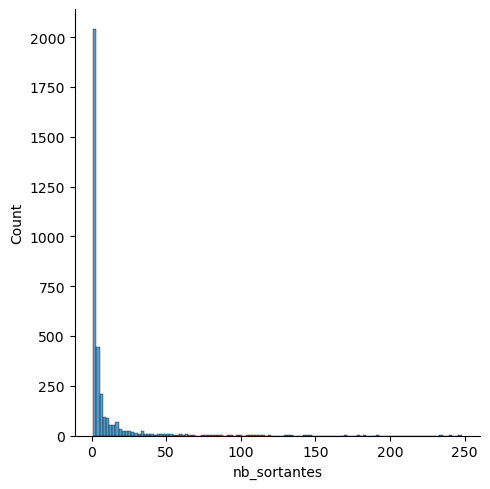

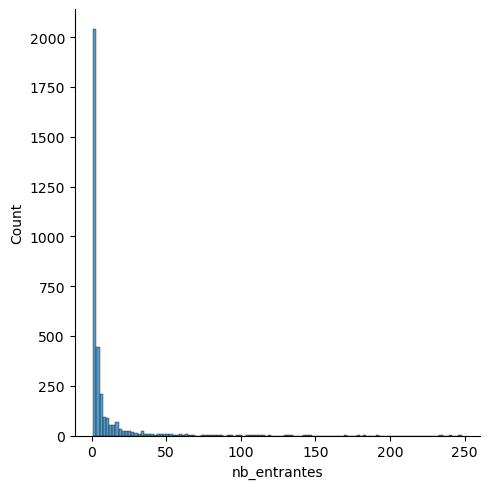

In [4]:
# graph sur les connexions
sns.displot(nb_connection_sortantes,
            x="nb_sortantes")

sns.displot(nb_connection_entrantes,
            x="nb_entrantes")

df_fusionne = pd.merge(nb_connection_sortantes, nb_connection_entrantes, on='airport', how='outer')


In [5]:
for key, item in data:
    print(f'{key} found in data')
    print(item)

edge_index found in data
tensor([[   0,    0,    1,  ..., 3361, 3361, 3362],
        [   1,    2,    0,  ..., 3359, 3362, 3361]])
country found in data
['FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'NEW_ZEALAND', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'USA', 'FRENCH_POLYNESIA', 'CHILE', 'FRENCH_POLYNESIA', 'USA', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'NEW_CALEDONIA', 'JAPAN', 'FRENCH_POLYNESIA', 'COOK_ISLANDS', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'JAPAN', 'WALLIS_AND_FUTUNA_ISLANDS', 'FRENCH_POLYNESIA', 'SAMOA', 'NEW_ZEALAND', 'AUSTRALIA', 'ARGENTINA', 'NEW_ZEALAND', 'AUSTRALIA', 'INDONESIA', 'NEW_ZEALAND', 'CHINA', 'NEW_ZEALAND', 'NIUE', 'NEW_ZEALAND', 'NEW_ZEALAND', 'MALAYSIA', 'AUSTRALIA', 'FIJI', 'JAPAN', 'AUSTRALIA', 'NEW_ZEALAND', 'NEW_ZEALAND', 'NEW_ZEALAND', 'AUSTRALIA', 'NEW_ZEALAND', 'NEW_ZEALAND', 'SOUTH_KOREA', 'SINGAPORE', 'AUSTRALIA

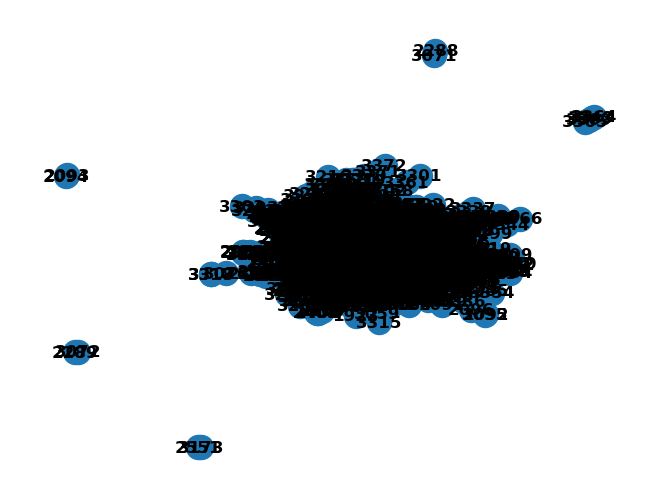

In [6]:

nx.draw(graph, with_labels=True, font_weight='bold')

In [7]:
#  on divise le set en train , val et test
from turtle import save

from torch import save
from torch_geometric.transforms import RandomLinkSplit

#transform = RandomLinkSplit(is_undirected=True)

transform = RandomLinkSplit(is_undirected=True,split_labels=True)
train_data, val_data, test_data = transform(data)
print(train_data)
print(val_data)
print(test_data)

save(train_data,'../data/train_data.pt')
save(val_data, '../data/val_data.pt')
save(test_data, '../data/test_data.pt')
save(data, '../data/data.pt')
print("sauvegarde terminée")

Data(edge_index=[2, 18968], country=[3363], city_name=[3363], x=[3363, 3], pos_edge_label=[9484], pos_edge_label_index=[2, 9484], neg_edge_label=[9484], neg_edge_label_index=[2, 9484])
Data(edge_index=[2, 18968], country=[3363], city_name=[3363], x=[3363, 3], pos_edge_label=[1354], pos_edge_label_index=[2, 1354], neg_edge_label=[1354], neg_edge_label_index=[2, 1354])
Data(edge_index=[2, 21676], country=[3363], city_name=[3363], x=[3363, 3], pos_edge_label=[2709], pos_edge_label_index=[2, 2709], neg_edge_label=[2709], neg_edge_label_index=[2, 2709])
sauvegarde terminée


array([1., 1., 1., ..., 1., 1., 1.], shape=(2709,), dtype=float32)